In [26]:
from pykoa.koa import Koa
from astropy.table import Table, Column
from astropy.io import fits
from pathlib import Path
from astropy.nddata import Cutout2D
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry
from astropy.stats import sigma_clipped_stats
from photutils.detection import DAOStarFinder
from astropy.visualization import (MinMaxInterval, SqrtStretch,
                                   ImageNormalize, LogStretch)

**Load in KOA**

In [2]:
koa_file = Path("/Users/bdigia/myg3/data/KOA_89772/NIRC2/raw/cal/N2.20160803.03304.fits")
koa_fits = fits.open(koa_file.as_posix())
koa_hdu = koa_fits[0]
koa_img = koa_fits[0].data
koa_hdr = koa_fits[0].header

In [3]:
# Purely for plotting purposes: 
SMALL_SIZE = 10
MEDIUM_SIZE = 11
BIGGER_SIZE = 13

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

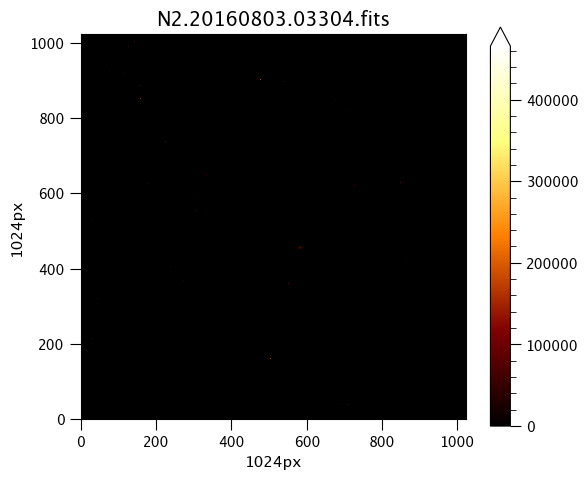

In [4]:
# Show original KOA image
fig, axes = plt.subplots()
plot = axes.imshow(koa_img, cmap="afmhot", vmin=0.0)
plt.title(f"{koa_file.name}", fontsize=14)
plt.xlabel("1024px")
plt.ylabel("1024px")
cbar = fig.colorbar(plot, extend="max", shrink=0.7)
cbar.minorticks_on()
plt.tight_layout()
plt.show()

**Centroid Sources**

In [5]:
# Use find_peaks sharpness and width, set threshold for snr (snr really high)

# Calculate statistics on image prior to processing
_, median, std = sigma_clipped_stats(koa_img, sigma=3.0) 
# Locate sources (as opposed to visual inspection) 
daofind = DAOStarFinder(fwhm=5.0, threshold=median + 30.0*std)  # nirc2 or osiris have 5 pixel fwhm
sources = daofind(koa_img)  
sources.pprint()

 id     xcentroid     ...        flux               mag        
--- ----------------- ... ----------------- -------------------
  1 580.5534120020501 ... 36.31674093152842  -3.900267169903433
  2 581.6603318891566 ... 1.272749427050985 -0.2618572755116017


In [6]:
"""
# Find coordinates of brightest pixel (highest flux)
if 'XSTREHL' in koa_hdr:
    print("Strehl coord keywords in FITS header")
    eng_coords = np.array([float(koa_hdr['XSTREHL']), float(koa_hdr['YSTREHL'])])
    # 0-index the coordinates
    eng_coords -= 1 

# Find engineering star coordinates (centroid on source) with initial guess
# from visual inspection of raw KOA image above
x_init = (575)
y_init = (450)
x, y = centroid_sources(koa_img, x_init, y_init, box_size=21,
                        centroid_func=centroid_com)
coords = np.column_stack((x, y))
print(coords[0])
"""

'\n# Find coordinates of brightest pixel (highest flux)\nif \'XSTREHL\' in koa_hdr:\n    print("Strehl coord keywords in FITS header")\n    eng_coords = np.array([float(koa_hdr[\'XSTREHL\']), float(koa_hdr[\'YSTREHL\'])])\n    # 0-index the coordinates\n    eng_coords -= 1 \n\n# Find engineering star coordinates (centroid on source) with initial guess\n# from visual inspection of raw KOA image above\nx_init = (575)\ny_init = (450)\nx, y = centroid_sources(koa_img, x_init, y_init, box_size=21,\n                        centroid_func=centroid_com)\ncoords = np.column_stack((x, y))\nprint(coords[0])\n'

In [6]:
# Find coordinates of brightest pixel
coords = np.array([0.0, 0.0])
coords[0] = sources['id'==np.argmax(sources['flux'])]['xcentroid']
coords[1] = sources['id'==np.argmax(sources['flux'])]['ycentroid']
print(coords)

[580.553412   454.23877842]


In [7]:
# Perform sky subtraction on image (we want to annulus to be far outside 
# the cropping zone, centered on source)
sky_aperture = CircularAnnulus(coords, 300, 400)
sky_aper_photo = aperture_photometry(koa_img, sky_aperture)
print(sky_aper_photo)
sky_sum = sky_aper_photo['aperture_sum'][0]
sky_avg = sky_sum/sky_aperture.area
koa_img_sub = koa_img - sky_avg
print(f"\nAverage pixel value in sky-subtracted KOA: {np.mean(koa_img_sub)}")
print(f"Maximum pixel value in sky-subtracted KOA: {np.max(koa_img_sub)}")

 id      xcenter           ycenter         aperture_sum   
           pix               pix                          
--- ----------------- ----------------- ------------------
  1 580.5534120020501 454.2387784190269 2742000.3687158455

Average pixel value in sky-subtracted KOA: 8.25883291720332
Maximum pixel value in sky-subtracted KOA: 465494.5313453531


**Sky Subtraction**

In [27]:
# Create interval object
interval = MinMaxInterval()
vmin, vmax = interval.get_limits(koa_img_sub)
# Create an ImageNormalize object using a SqrtStretch object
norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=LogStretch())

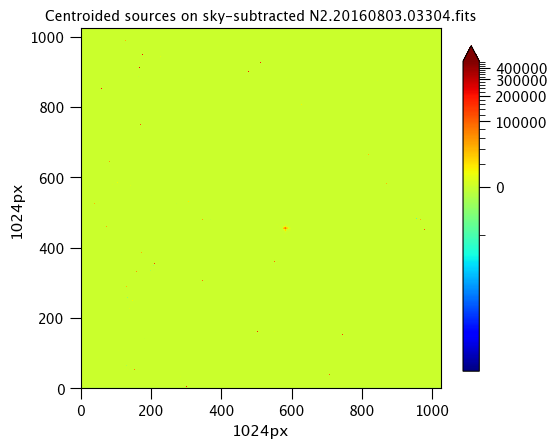

In [30]:
# Plot sky subtracted image, prior to cropping, including centroids
positions = np.transpose((sources['xcentroid'], sources['ycentroid']))
apertures = CircularAperture(positions, r=7.0)
fig, axes = plt.subplots()
plot = axes.imshow(koa_img_sub, cmap="afmhot", norm=norm)
# apertures.plot(color='white', lw=0.75, alpha=1.0)
plt.title(f"Centroided sources on sky-subtracted {koa_file.name}")
plt.xlabel("1024px")
plt.ylabel("1024px")
cbar = fig.colorbar(plot, extend="max", shrink=0.7)
cbar.minorticks_on()
plt.show()

**Crop Sky-subtracted KOA Image**

In [10]:
# Crop image around peak pixel
cutout_obj = Cutout2D(koa_img_sub, coords, [256, 256], mode='trim')
# Normalize by integral of entire PSF (as opposed to peak pixel value)
cropped_img = cutout_obj.data
img_norm = cropped_img/np.sum(cropped_img)
# Save normalization constant for each cropped KOA image to track outliers
# (contributions from hot pixels, cosmic rays, etc.)
with open('/Users/bdigia/myg3/data/KOA_norm_constants.csv', 'a+') as const_file:
    # Only write if this image's normalization has yet to be recorded
    to_write = f"{koa_file.name}: {np.sum(cropped_img)}\n"
    lines = const_file.readlines()
    for line in lines:
        if to_write in line:
            # Line is found in file, no need to inspect further or write
            # anything to file
            print("Already written to file.")
            break
    else:
        # Line was not found anywhere in file, so write it
        const_file.write(to_write)

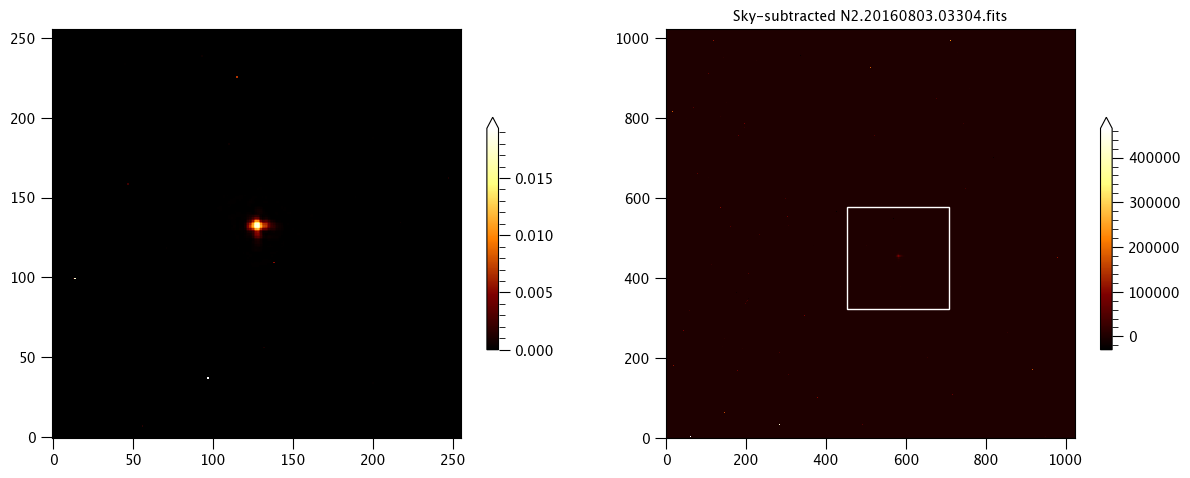

In [13]:
# Show cropped KOA image post-normalization
fig, (axes1, axes2) = plt.subplots(1, 2, figsize=(15, 15))
plot1 = axes1.imshow(img_norm, cmap="afmhot", vmin=0.0)
plt.title(f"Sky-subtracted, normalized {koa_file.name}")
cbar1 = fig.colorbar(plot1, extend="max", shrink=0.2)
cbar1.minorticks_on()

plot2 = axes2.imshow(koa_img_sub, cmap="afmhot")
cutout_obj.plot_on_original(color='white')
plt.title(f"Sky-subtracted {koa_file.name}")
cbar2 = fig.colorbar(plot2, extend="max", shrink=0.2)
cbar2.minorticks_on()

**Store Cropped, Sky-subtracted KOA FITS**

In [ ]:
# Save cropped KOA image as separate FITS file in same directory
# of original file
new_koa_file = Path("/Users/bdigia/myg3/data/KOA_89772/NIRC2/raw/cal/N2.20160803.03304.processed.fits")
new_hdu = fits.PrimaryHDU(img_norm)
new_hdu.writeto(new_koa_file.as_posix())